pystran - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# A 2-D truss sizing optimization: Hollow tubes.

Last updated: 06/27/26

## Description

Optimize the cross sectional properties of a truss structure to achieve its 
minimum weight. The bars are manufactured out of hollow circular tubes.

The bars are grouped into four groups: bottom chord, top chord,
verticals, and diagonals. Each group has its own individual
cross sectional properties (inner radius of the tube and the thickness of the wall).

Objective function: mass of the structure. The design variables are the 
inner radii and thicknesses of the wall for each group of bars.

Constraints: (1) limit on maximum deflection, and (2) the design variables 
are bounded from below so that the thickness of the wall must be greater than or equal to 1 mm,
and the inner radius must be greater than equal to 5 mm. The second constraint is treated as
a lower bound on the design variables.

Mathematically
$$
       x^* = \arg\min f(x)
$$
subject to the constraint
$$
    c_j(x) \ge 0 \; , j=1,2
$$
Note: $f(x)$ is the objective function, whose argument is the vector of the design variables, $x$.



First we bring in the modules and functions that we will need.

In [234]:
import context
from math import pi
from numpy import max, ones
from pystran import model
from pystran import section
from pystran import plots
from scipy.optimize import minimize

We are working in SI(mm) units. Now, we define some useful constants.

In [235]:
INITIAL_INNER_RADIUS = 15.0
INITIAL_WALL_THICKNESS = 2.0

The minimum wall thickness is 1mm. The smallest inner radius is 10mm.
These constraint will be enforced by the "lower bound" constraint defined below.

In [236]:
SMALLEST_INNER_RADIUS = 5.0
SMALLEST_WALL_THICKNESS = 1.0


Maximum allowed deflection (in millimeters)


In [237]:
MAXIMUM_ALLOWED_DEFLECTION = 20.0


The material properties correspond roughly to steel.


In [238]:
E = 200000
RHO = 7.8e-9


The magnitude of the vertical (downward) forces in Newton.


In [239]:
W = 6000


A function to calculate the area of a bar is defined that uses the  nondimensional values of the design variables, the first for the radius and the second for the wall thickness, 
to calculate the real radius and wall thickness, and then the area.

In [240]:
def _area(nr, nt):
    r = INITIAL_INNER_RADIUS * nr
    t = INITIAL_WALL_THICKNESS * nt 
    return pi * ((r + t)**2 - r**2)

The design variables are nondimensional multipliers of the initial inner radius of each group, followed by the nondimensional multipliers of the wall thickness of each group. The cross sectional area of each group `i` of bars is `_area(dvs[i], dvs[i+NGROUPS])`. The design variables start at the value of 1.0.


In [241]:
dvs0 = ones(2 * NGROUPS)

Now we define the groups of bars. `group_bars` is a list of lists. 

In [242]:
group_names = ["bottom_chord", "top_chord", "verticals", "diagonals"]
NGROUPS = len(group_names)
group_bars = [
    [ # bottom_chord
        [1, 2],
        [2, 3],
        [3, 4],
        [4, 5],
    ],
    [ # top_chord
        [6, 7],
        [7, 8],
        [8, 9],
        [9, 10],
    ],
    [ # verticals
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
        [5, 10],
    ],
    [ # diagonals
        [1, 7],
        [3, 9],
        [3, 7],
        [5, 9],
    ]
    ]


This function defines the `pystran` model of the structure, based on the values of the
design variables, `dvs`. 


In [243]:
def truss_model(dvs):
    m = model.create(2)
    freedoms = m['freedoms']
    model.add_joint(m, 1, [-6000, -2500])
    model.add_joint(m, 2, [-3000, -2500])
    model.add_joint(m, 3, [0, -2500])
    model.add_joint(m, 4, [3000, -2500])
    model.add_joint(m, 5, [6000, -2500])
    model.add_joint(m, 6, [-6000, 0])
    model.add_joint(m, 7, [-3000, 0])
    model.add_joint(m, 8, [0, 0])
    model.add_joint(m, 9, [3000, 0])
    model.add_joint(m, 10, [6000, 0])
    model.add_support(m["joints"][1], freedoms.U2)
    model.add_support(m["joints"][5], freedoms.U2)
    model.add_support(m["joints"][8], freedoms.U1)
    model.add_load(m["joints"][2], freedoms.U2, -W)
    model.add_load(m["joints"][3], freedoms.U2, -W)
    model.add_load(m["joints"][4], freedoms.U2, -W)
    for g in range(NGROUPS):
        s = section.truss_section(f"s{group_names[g]}", E=E, A=_area(dvs[g], dvs[g+NGROUPS]), rho=RHO)
        for k, c in enumerate(group_bars[g]):
            model.add_truss_member(m, f"{group_names[g]}_{k}", c, s)
    return m

At this point we can display the initial structure: members, joints, applied forces, and supports.


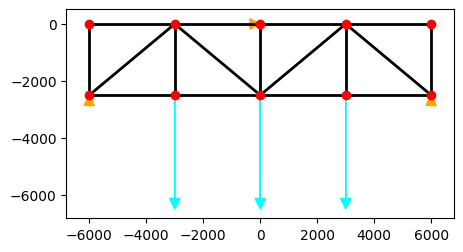

In [244]:
m = truss_model(dvs0)
plots.setup(m)
plots.plot_members(m)
plots.plot_joints(m)
plots.plot_applied_forces(m)
plots.plot_translation_supports(m)
plots.show(m)

The following calculates the total volume of all 
the members of the structure. We can use it to evaluate 
the total mass of the structure. 


In [245]:
mass = RHO * model.volume(m)
print('Initial mass = ', 1000 * mass, ' [kg]')

Initial mass =  81.73969583025206  [kg]


This helper function is defined to compute the design 
responses (`drs`). Static response of the structure is computed. 

The design responses are the mass of the structure and  the maximum displacement magnitude. They are returned as a tuple.


In [246]:
def solve(dvs):
    m = truss_model(dvs)
    model.number_dofs(m)
    model.solve_statics(m)
    drs = (
        RHO * model.volume(m),
        max(abs(m["U"])),
    )
    return drs

Now we can report on the performance of the structure 
as originally designed.


In [247]:
drs = solve(dvs0)
initial_mass = drs[0]
initial_max_deflection = drs[1]
print("\nInitial structure")
print("-----------------")
print("Initial Design Variables: ", dvs0)
print("Mass: ", 1000 * initial_mass, ' [kg]')
print("Initial largest deflection: ", initial_max_deflection, '[mm]')



Initial structure
-----------------
Initial Design Variables:  [1. 1. 1. 1. 1. 1. 1. 1.]
Mass:  81.73969583025206  [kg]
Initial largest deflection:  7.35549627683702 [mm]


At this point we start on the optimization. The objective 
function and the constraints need to be defined. The objective function value has the meaning of current mass normalized by the initial mass. Therefore the objective function value will be in reasonable bounds (close to 1.0).

In [248]:
# Objective function is the normalized mass.
def objective(dvs):
    drs = solve(dvs)
    return drs[0] / initial_mass

Define a constraint on the maximum deflection.  The constraint here is on the maximum deflection, $(u_{max}-\max u)/u_{max}\ge 0$: Here $u_{max}$=`MAXIMUM_ALLOWED_DEFLECTION`.

In [249]:
def constrain_deflection(dvs):
    drs = solve(dvs)
    max_deflection = drs[1]
    return (MAXIMUM_ALLOWED_DEFLECTION - max_deflection) / MAXIMUM_ALLOWED_DEFLECTION

cons = [
    {"type": "ineq", "fun": constrain_deflection},
]

The function `constrain_deflection` is used to define an inequality constraint. All such constraints are collected in the list `cons`.




Define lower bounds for the design variables. There are no upper bounds (the `None`).
The lower bound consists of two lists: the first one for the inner radius design variables, and the second for the thickness design variables.


In [250]:
bounds = [(SMALLEST_INNER_RADIUS / INITIAL_INNER_RADIUS, None) for _ in range(NGROUPS)] + [(SMALLEST_WALL_THICKNESS / INITIAL_WALL_THICKNESS, None) for _ in range(NGROUPS)]

Invoke the optimization function. 


In [251]:
solution = minimize(
    objective,
    dvs0,
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"ftol": 1e-7, "maxiter": 1000, "disp": True},
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.31990069198739685
            Iterations: 8
            Function evaluations: 72
            Gradient evaluations: 8


Retrieve the values of the design variables from the solution, and compute the design responses
for the optimal design variables.

In [252]:
dvs = solution.x
drs = solve(dvs)

 Now report the characteristics of the optimized structure. The largest deflection is equal to the maximum allowed, and that constraint is then the only active constraint.

In [253]:
mass = drs[0]
max_deflection = drs[1]
print("\nOptimized structure")
print("-----------------")
print("Solution success: ", solution.success, f" ({solution.nit} iterations)")
print("Design Variables: ", dvs)
print("Mass: ", 1000 * mass, ' [kg]')
print("Largest deflection: ", max_deflection, '[mm]')


Optimized structure
-----------------
Solution success:  True  (8 iterations)
Design Variables:  [0.61463656 0.65497839 0.33333333 0.62955942 0.55971067 0.60594001
 0.5        0.58037266]
Mass:  26.148585258936972  [kg]
Largest deflection:  20.000000003304905 [mm]


Print out the parameters of the cross sectional areas of the four groups (in mm**2 and mm respectively).


In [254]:
print("Areas of groups of bars: ")
m = truss_model(dvs)
for g in range(NGROUPS):
    print(f"Group {group_names[g]} area: {_area(dvs[g], dvs[g+NGROUPS])} (radius {INITIAL_INNER_RADIUS * dvs[g]}, wall thickness {INITIAL_WALL_THICKNESS * dvs[g+NGROUPS]})")

Areas of groups of bars: 
Group bottom_chord area: 68.78272833460761 (radius 9.219548340526753, wall thickness 1.1194213388421317)
Group top_chord area: 79.42357712325853 (radius 9.824675852100711, wall thickness 1.2118800143489659)
Group verticals area: 34.557519189487735 (radius 5.000000000000002, wall thickness 1.0)
Group diagonals area: 73.10509378877103 (radius 9.443391315792308, wall thickness 1.1607453122666045)


It is noteworthy that given the initial values of the design variables, the structure meets the deflection constraint, while at the same time the verticals are as small as allowed (note that the inner radius and thickness of the wall are equal to the limits).

The following visualization provides a graphical assessment of the optimized structure: bars with large cross sectional area are shown with thick lines, and conversely bars whose cross sectional area is small are thin.

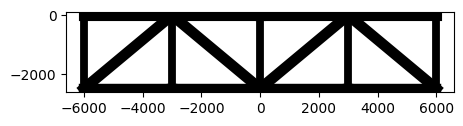

In [255]:
plots.setup(m)
plots.plot_members(m, min_linewidth=1, max_linewidth=8)
plots.show(m)

## Conclusions

The structure was optimized using realistic steel profiles. The profiles are quite thin-walled. The attained mass of the structure is quite low.
